In [94]:
import numpy as np 
import matplotlib.pyplot as plt
import tensorflow as tf 
from tensorflow import keras 
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPool2D
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import cifar10


In [95]:
np.random.seed(42)
tf.random.set_seed(42)

In [96]:
(x_train, y_train) ,(x_test, y_test) = cifar10.load_data()

In [97]:
print(cifar10.load_data.__doc__)

Loads the CIFAR10 dataset.

    This is a dataset of 50,000 32x32 color training images and 10,000 test
    images, labeled over 10 categories. See more info at the
    [CIFAR homepage](https://www.cs.toronto.edu/~kriz/cifar.html).

    The classes are:

    | Label | Description |
    |:-----:|-------------|
    |   0   | airplane    |
    |   1   | automobile  |
    |   2   | bird        |
    |   3   | cat         |
    |   4   | deer        |
    |   5   | dog         |
    |   6   | frog        |
    |   7   | horse       |
    |   8   | ship        |
    |   9   | truck       |

    Returns:
        Tuple of NumPy arrays: `(x_train, y_train), (x_test, y_test)`.

    **`x_train`**: `uint8` NumPy array of grayscale image data with shapes
      `(50000, 32, 32, 3)`, containing the training data. Pixel values range
      from 0 to 255.

    **`y_train`**: `uint8` NumPy array of labels (integers in range 0-9)
      with shape `(50000, 1)` for the training data.

    **`x_test`**: `uin

In [98]:
class_name = [

     'automobile',  
     'bird',        
     'cat',         
     'deer',        
     'dog',         
     'frog',        
     'horse',       
     'ship',        
     'truck'  
]

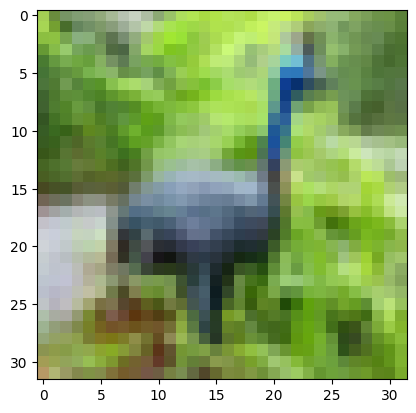

cat


In [99]:
index = 6
plt.imshow(x_train[index], cmap='gray')
plt.show()
print(class_name[y_train[index][0]])

In [100]:
x_train.shape

(50000, 32, 32, 3)

In [101]:
y_train.shape

(50000, 1)

In [102]:
x_test.shape

(10000, 32, 32, 3)

In [103]:
y_test.shape

(10000, 1)

In [104]:
x_test.max()

np.uint8(255)

In [105]:
x_train = x_train / 255
x_test = x_test / 255

In [106]:
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

In [107]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [108]:
data_gen =ImageDataGenerator(width_shift_range=.1,
                             height_shift_range=.1,
                             horizontal_flip=True,
                             fill_mode ='nearest')

In [109]:
batch_size = 10

In [110]:
from sklearn.model_selection import train_test_split

In [111]:
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=.2, random_state=42)

In [112]:
train_data_gen = data_gen.flow(x=x_train, y=y_train, batch_size=batch_size)

In [113]:
batch = next(train_data_gen)
batch[0].shape

(10, 32, 32, 3)

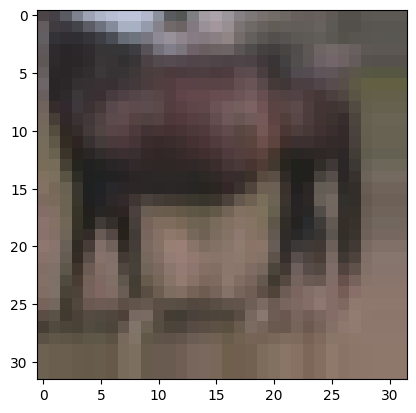

In [114]:
plt.imshow(batch[0][0])

In [115]:
class_name[batch[1][0].argmax()]

'ship'

In [116]:
reg = keras.regularizers.l2(.003)

In [117]:
# model architecture

model = keras.models.Sequential()
model.add(Conv2D(filters=32, kernel_size=(3,3), strides=1, padding='same', activation='relu', 
                 kernel_regularizer=reg, input_shape=(32,32,3), name= 'Conv1'))
model.add(Dropout(.25, name = 'drop1'))
model.add(Conv2D(filters=32, kernel_size=(3,3), strides=1, padding="same", activation='relu', kernel_regularizer=reg, name='Conv2'))
model.add(Dropout(.25, name = 'drop2'))
model.add(MaxPool2D(name='pool1'))
model.add(Conv2D(filters=64, kernel_size=(3,3), strides=1, padding="same", activation='relu', kernel_regularizer=reg, name='Conv3'))
model.add(Dropout(.25, name = 'drop3'))
model.add(Conv2D(filters=64, kernel_size=(3,3), strides=1, padding="same", activation='relu', kernel_regularizer=reg, name='Conv4'))
model.add(Dropout(.25, name = 'drop4'))
model.add(MaxPool2D(name='pool2'))
model.add(Conv2D(filters=128, kernel_size=(3,3), strides=1, padding="same", activation='relu', kernel_regularizer=reg, name='Conv5'))
model.add(Dropout(.25, name = 'drop5'))
model.add(Conv2D(filters=128, kernel_size=(3,3), strides=1, padding="same", activation='relu', kernel_regularizer=reg, name='Conv6'))
model.add(Dropout(.25, name = 'drop6'))
model.add(Flatten(name='flatten'))
model.add(Dense(units=512, activation='relu', kernel_regularizer=reg, name ='hidden1'))
model.add(Dropout(.5, name = 'drop7'))
model.add(Dense(units=10, activation='softmax', kernel_regularizer=reg, name ='output'))

/Users/taktakro/Desktop/SmallProjects_PY/venv3.12/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [118]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Conv1 (Conv2D)                  │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop1 (Dropout)                 │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv2 (Conv2D)                  │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop2 (Dropout)                 │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv3 (Conv2D)                  │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop3 (Dropout)                 │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv4 (Conv2D)                  │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop4 (Dropout)                 │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv5 (Conv2D)                  │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop5 (Dropout)                 │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv6 (Conv2D)                  │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop6 (Dropout)                 │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden1 (Dense)                 │ (None, 512)            │     4,194,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop7 (Dropout)                 │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,486,954 (17.12 MB)

 Trainable params: 4,486,954 (17.12 MB)

 Non-trainable params: 0 (0.00 B)

In [119]:
# complile model
opt = tf.optimizers.Adam(learning_rate=.001)
loss = tf.losses.CategoricalCrossentropy()
metric = tf.metrics.CategoricalAccuracy()
model.compile(optimizer=opt, loss=loss, metrics=[metric])

In [120]:
model.fit(train_data_gen, epochs=10, batch_size=batch_size, validation_data=(x_val, y_val), verbose=2)

Epoch 1/100


/Users/taktakro/Desktop/SmallProjects_PY/venv3.12/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


4000/4000 - 92s - 23ms/step - categorical_accuracy: 0.0984 - loss: 2.3464 - val_categorical_accuracy: 0.0996 - val_loss: 2.3030
Epoch 2/100
4000/4000 - 194s - 48ms/step - categorical_accuracy: 0.0989 - loss: 2.3029 - val_categorical_accuracy: 0.0933 - val_loss: 2.3029
Epoch 3/100
4000/4000 - 208s - 52ms/step - categorical_accuracy: 0.0986 - loss: 2.3029 - val_categorical_accuracy: 0.0933 - val_loss: 2.3030
Epoch 4/100
4000/4000 - 122s - 31ms/step - categorical_accuracy: 0.0993 - loss: 2.3028 - val_categorical_accuracy: 0.0973 - val_loss: 2.3032
Epoch 5/100
4000/4000 - 127s - 32ms/step - categorical_accuracy: 0.0981 - loss: 2.3030 - val_categorical_accuracy: 0.0973 - val_loss: 2.3027
Epoch 6/100
4000/4000 - 126s - 32ms/step - categorical_accuracy: 0.0989 - loss: 2.3029 - val_categorical_accuracy: 0.0979 - val_loss: 2.3029
Epoch 7/100
4000/4000 - 114s - 29ms/step - categorical_accuracy: 0.0998 - loss: 2.3029 - val_categorical_accuracy: 0.0933 - val_loss: 2.3030
Epoch 8/100
4000/4000 - 10

KeyboardInterrupt: 

In [121]:
model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - categorical_accuracy: 0.1036 - loss: 2.3026


[2.3026373386383057, 0.10000000149011612]

In [122]:
model.save('model/model_fashion_mnist.h5')  #HDFS

In [123]:
model.save_weights("models/weights_fashion_mnist.h5")

ValueError: The filename must end in `.weights.h5`. Received: filepath=models/weights_fashion_mnist.h5

In [124]:
with open("models/architecture.json", "w") as f:
    f.write(model.to_json())

FileNotFoundError: [Errno 2] No such file or directory: 'models/architecture.json'

In [125]:
from PIL import Image, ImageOps
img = Image.open('image.jpg')
img.thumbnail((28,28))
grayscale_img = img.convert("L")
grayscale_img = ImageOps.invert(grayscale_img)
grayscale_img = np.array(grayscale_img).reshape((1,28,28)) / 255

FileNotFoundError: [Errno 2] No such file or directory: 'image.jpg'

In [126]:
pred_img = model.predict(grayscale_img)
class_name[pred_img.argmax()]

NameError: name 'grayscale_img' is not defined